# 長短期記憶模型 (Long Short-Term Memory, LSTM)

In [ ]:
import numpy as np

# 指定要讀取的文字檔路徑
filename = "data/shakespeare.txt"

# 讀取整個文字檔內容
data = open(filename, "r").read()
# 取得資料中所有不重複字元，建立字元表
chars = list(set(data))
# 計算全文字元總數與不重複字元數量
data_size, vocab_size = len(data), len(chars)

# 輸出資料集的基本統計資訊
print("字元總數 %d, 字符表的長度 %d unique." % (data_size, vocab_size))
# 顯示字元表中的前 10 個字元，方便快速查看字元組成
print("字元表中的前 10 個字元：\n", chars[:10])
# 顯示原始文字前 148 個字元，作為資料內容預覽
print("前 148 個字元：\n", data[:148])

# 建立字元到索引的映射表，方便將文字資料轉成模型可處理的數值表示
char_to_idx = {ch: i for i, ch in enumerate(chars)}

# 建立索引到字元的映射表，方便之後將模型輸出還原成文字
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# 輸出雙向映射內容，確認字元表與索引配置是否正確
print("字元到索引的映射：\n", char_to_idx)
print("索引到字元的映射：\n", idx_to_char)


def one_hot_idx(idx, vocab_size):
    # 建立一個大小為 (1, vocab_size) 的全 0 向量
    x = np.zeros((1, vocab_size))

    # 將指定索引位置設為 1，形成 one-hot 表示
    x[0, idx] = 1

    # 回傳 one-hot 向量
    return x


# 測試 one_hot_idx 函數，將索引 1 轉換為 one-hot 向量
test_idx = 1
one_hot_vector = one_hot_idx(char_to_idx["B"], vocab_size)

# 輸出測試結果
print("索引 %d 的 one-hot 向量：\n" % test_idx, one_hot_vector)

字元總數 1115394, 字符表的長度 65 unique.
字元表中的前 10 個字元：
 ['g', 'y', 'W', '&', 'P', 'e', 'w', 'H', ':', 'B']
前 148 個字元：
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

字元到索引的映射：
 {'g': 0, 'y': 1, 'W': 2, '&': 3, 'P': 4, 'e': 5, 'w': 6, 'H': 7, ':': 8, 'B': 9, ' ': 10, 'f': 11, 'v': 12, 'D': 13, 'X': 14, 'L': 15, 'O': 16, 'h': 17, 's': 18, 'F': 19, 'E': 20, 'z': 21, 'Z': 22, 'i': 23, 'l': 24, 'm': 25, '?': 26, '$': 27, 'U': 28, 'a': 29, 'b': 30, '.': 31, '\n': 32, 'A': 33, '!': 34, 'G': 35, 'K': 36, 'j': 37, 'C': 38, 'o': 39, ';': 40, 'J': 41, 'T': 42, 'c': 43, 'q': 44, 't': 45, 'R': 46, ',': 47, 'S': 48, '-': 49, 'n': 50, 'd': 51, 'V': 52, '3': 53, 'k': 54, 'I': 55, 'Y': 56, 'M': 57, 'x': 58, 'p': 59, 'r': 60, "'": 61, 'N': 62, 'Q': 63, 'u': 64}
索引到字元的映射：
 {0: 'g', 1: 'y', 2: 'W', 3: '&', 4: 'P', 5: 'e', 6: 'w', 7: 'H', 8: ':', 9: 'B', 10: ' ', 11: 'f', 12: 'v', 13: 'D', 14: 'X', 15: 'L', 16: 'O

## 初始化

In [ ]:
import numpy as np


def lstm_params_init(input_dim, hidden_dim, output_dim, scale=0.01):
    # 建立常態分布隨機初始化函式，用於產生權重矩陣
    normal = lambda m, n: np.random.randn(m, n) * scale

    # 建立單一 gate 的權重與偏置
    # 權重輸入維度為 input_dim + hidden_dim，輸出維度為 hidden_dim
    two = lambda: (
        normal(input_dim + hidden_dim, hidden_dim),
        np.zeros((1, hidden_dim)),
    )

    # 各 gate 參數初始化
    Wi, bi = two()  # Input gate parameters
    Wf, bf = two()  # Forget gate parameters
    Wo, bo = two()  # Output gate parameters
    Wc, bc = two()  # Candidate cell parameters

    # 輸出層參數初始化
    Wy = normal(hidden_dim, output_dim)
    by = np.zeros((1, output_dim))

    # 依固定順序整理所有參數，供前向傳播函式使用
    params = [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by]
    return params


def lstm_state_init(batch_size, hidden_size):
    # 初始化隱藏狀態 H 與記憶狀態 C
    return (np.zeros((batch_size, hidden_size)), np.zeros((batch_size, hidden_size)))

## 向前傳播

這段程式碼實作的是 LSTM（Long Short-Term Memory）在處理時間序列資料時的向前傳播流程。  

![alt text](https://images.vocus.cc/b99a0bc3-5338-47ec-ba12-3cecf738cb02.jpg)

* Forget Gate (遺忘門)
    $$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)$$

* Input Gate (輸入門)
    $$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)$$

* Candidate Memory (候選記憶)
    $$\tilde{C}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)$$

* Cell State (單元狀態更新)
    $$C_t = f_t C_{t-1} + i_t \tilde{C}_t$$

* Output Gate (輸出門)
    $$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)$$

* Final Hidden State (最終隱藏狀態)
    $$h_t = o_t \odot \tanh(C_t)$$

### 總結：LSTM 資料流 (Data Flow)

這是一個完整的時間步 ($t$) 運算過程：

**輸入** $\rightarrow$ **Gate 運算** $\rightarrow$ **記憶更新** $\rightarrow$ **輸出**

$$(x_t, h_{t-1}) \rightarrow (f_t, i_t, o_t, \tilde{C}_t) \rightarrow C_t \rightarrow h_t$$

流程拆解：
1. **輸入與隱藏狀態**：接收當前輸入 $x_t$ 與前一刻的隱藏狀態 $h_{t-1}$。
2. **門控邏輯**：同時計算遺忘門 ($f_t$)、輸入門 ($i_t$)、輸出門 ($o_t$) 以及候選記憶 ($\tilde{C}_t$)。
3. **記憶更新**：利用 $f_t$ 遺忘舊記憶，$i_t$ 寫入新記憶，得到新的單元狀態 $C_t$。
4. **最終輸出**：透過 $o_t$ 過濾 $C_t$ 的資訊，輸出當前的隱藏狀態 $h_t$。

In [ ]:
def sigmoid(x):
    # sigmoid 啟用函式
    return 1 / (1 + np.exp(-x))


def lstm_forward(params, Xs, state):
    # 取出所有 LSTM 與輸出層參數
    [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by] = params

    # 初始 hidden state 與 cell state
    (H, C) = state  # 初始状态

    # 儲存每個時間步的 hidden state 與 cell state
    Hs = {}
    Cs = {}

    # 儲存每個時間步的輸出結果
    Zs = []

    # 額外保留初始狀態，方便後續存取
    Hs[-1] = np.copy(H)
    Cs[-1] = np.copy(C)

    # 儲存每個時間步的 gate 與候選 cell 結果
    Is = []
    Fs = []
    Os = []
    C_tildas = []

    # 逐時間步處理輸入序列
    for t in range(len(Xs)):
        X = Xs[t]

        # 將當前輸入與前一時刻 hidden state 串接
        XH = np.column_stack((X, H))

        # 除錯用區塊，目前不會執行
        if False:
            print("XH.shape", XH.shape)
            print("Wi.shape", Wi.shape)
            break

        # 計算三個 gate 與候選 cell 狀態
        I = sigmoid(np.dot(XH, Wi) + bi)
        F = sigmoid(np.dot(XH, Wf) + bf)
        O = sigmoid(np.dot(XH, Wo) + bo)
        C_tilda = np.tanh(np.dot(XH, Wc) + bc)

        # 更新 cell state
        C = F * C + I * C_tilda

        # 更新 hidden state
        H = O * np.tanh(C)  # O * C.tanh()  #输出状态

        # 經輸出層得到當前時間步輸出
        Y = np.dot(H, Wy) + by  # 输出

        # 紀錄當前時間步結果
        Zs.append(Y)
        Hs[t] = H
        Cs[t] = C

        # 紀錄各 gate 與候選 cell 結果
        Is.append(I)
        Fs.append(F)
        Os.append(O)
        C_tildas.append(C_tilda)

    # 回傳整段序列輸出、各時間步狀態，以及中間 gate 結果
    return Zs, Hs, Cs, (Is, Fs, Os, C_tildas)


def lstm_forward_step(params, X, H, C):
    # 取出所有 LSTM 與輸出層參數
    [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by] = params

    # 將當前輸入與前一時刻 hidden state 串接
    XH = np.column_stack((X, H))

    # 計算三個 gate 與候選 cell 狀態
    I = sigmoid(np.dot(XH, Wi) + bi)
    F = sigmoid(np.dot(XH, Wf) + bf)
    O = sigmoid(np.dot(XH, Wo) + bo)
    C_tilda = np.tanh(np.dot(XH, Wc) + bc)

    # 更新 cell state 與 hidden state
    C = F * C + I * C_tilda
    H = O * np.tanh(C)  # O * tanh(C)  #输出状态

    # 經輸出層得到單一步驟輸出
    Y = np.dot(H, Wy) + by  # 输出

    # 回傳輸出、更新後狀態，以及當前步驟的 gate 結果
    return Y, H, C, (I, F, O, C_tilda)

## 反向傳播

In [ ]:
import math


def dsigmoid(x):
    # sigmoid 的導數
    return sigmoid(x) * (1 - sigmoid(x))


def dtanh(x):
    # tanh 的導數
    return 1 - np.tanh(x) * np.tanh(x)


def grad_clipping(grads, alpha):
    # 計算所有梯度的整體 L2 norm
    norm = math.sqrt(sum((grad**2).sum() for grad in grads))

    # 若超過門檻，則按比例縮放所有梯度
    if norm > alpha:
        ratio = alpha / norm
        for i in range(len(grads)):
            grads[i] *= ratio


def lstm_backward(params, Xs, Hs, Cs, dZs, cache, clip_value=5.0):  # Ys,loss_function):
    # 取出 LSTM 與輸出層參數
    [Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by] = params

    # 取出前向傳播保留的 gate 與候選 cell 結果
    Is, Fs, Os, C_tildas = cache

    # 初始化各參數梯度
    dWi, dWf, dWo, dWc, dWy = (
        np.zeros_like(Wi),
        np.zeros_like(Wf),
        np.zeros_like(Wo),
        np.zeros_like(Wc),
        np.zeros_like(Wy),
    )
    dbi, dbf, dbo, dbc, dby = (
        np.zeros_like(bi),
        np.zeros_like(bf),
        np.zeros_like(bo),
        np.zeros_like(bc),
        np.zeros_like(by),
    )

    # 初始化從下一時間步回傳的 hidden state 與 cell state 梯度
    dH_next = np.zeros_like(Hs[0])
    dC_next = np.zeros_like(Cs[0])

    # 取得輸入特徵維度，用於後續拆分 dXH_
    input_dim = Xs[0].shape[1]

    # 簡化變數名稱
    h = Hs
    x = Xs

    # 序列長度
    T = len(Xs)

    # 依時間反向走訪
    for t in reversed(range(T)):
        # 取出當前時間步前向傳播保存的中間結果
        I = Is[t]
        F = Fs[t]
        O = Os[t]
        C_tilda = C_tildas[t]
        H = Hs[t]
        X = Xs[t]
        C = Cs[t]
        H_pre = Hs[t - 1]
        C_prev = Cs[t - 1]

        # 將當前輸入與前一時刻 hidden state 串接
        XH_pre = np.column_stack((X, H_pre))
        XH_ = XH_pre

        # 當前時間步來自輸出端的梯度
        dZ = dZs[t]

        # 輸出層參數梯度
        dWy += np.dot(H.T, dZ)
        dby += np.sum(dZ, axis=0, keepdims=True)

        # hidden state 的總梯度
        # 包含目前輸出層傳回的梯度，以及下一時間步回傳的梯度
        dH = np.dot(dZ, Wy.T) + dH_next

        # cell state 的總梯度
        dC = dH * O * dtanh(C) + dC_next  # H_t= O_t*tanh(C_t)

        # output gate 梯度
        dO = np.tanh(C) * dH
        dOZ = O * (1 - O) * dO  # O = sigma(Z_o)
        dWo += np.dot(XH_.T, dOZ)  # Z_o = (X,H_)W_o+b_o
        dbo += np.sum(dOZ, axis=0, keepdims=True)

        # input gate 梯度
        di = C_tilda * dC
        diZ = I * (1 - I) * di
        dWi += np.dot(XH_.T, diZ)
        dbi += np.sum(diZ, axis=0, keepdims=True)

        # forget gate 梯度
        df = C_prev * dC
        dfZ = F * (1 - F) * df
        dWf += np.dot(XH_.T, dfZ)
        dbf += np.sum(dfZ, axis=0, keepdims=True)

        # 候選 cell 狀態梯度
        dC_tilda = I * dC  # C = F * C + I * C_tilda
        dC_tilda_Z = (1 - np.square(C_tilda)) * dC_tilda  # C_tilda = tanh(C_tilda_Z)
        dWc += np.dot(XH_.T, dC_tilda_Z)  # C_tilda_Z = (X,H_)W_c+b_c
        dbc += np.sum(dC_tilda_Z, axis=0, keepdims=True)

        # 將各 gate 傳回輸入與前一 hidden state 的梯度合併
        dXH_ = (
            np.dot(dfZ, Wf.T)
            + np.dot(diZ, Wi.T)
            + np.dot(dC_tilda_Z, Wc.T)
            + np.dot(dOZ, Wo.T)
        )

        # 拆出對輸入與前一 hidden state 的梯度
        dX_prev = dXH_[:, :input_dim]
        dH_prev = dXH_[:, input_dim:]

        # 傳回前一 cell state 的梯度
        dC_prev = F * dC

        # 更新傳給前一時間步的梯度
        dC_next = dC_prev
        dH_next = dH_prev

    # 整理所有參數梯度
    grads = [dWi, dbi, dWf, dbf, dWo, dbo, dWc, dbc, dWy, dby]

    # 做梯度裁切，避免梯度爆炸
    grad_clipping(grads, clip_value)

    # for dparam in [dWi, dbi,dWf, dbf, dWo,dbo,dWc, dbc,dWy,dby]:
    #    np.clip(dparam, -5, 5, out=dparam) # clip to mitigate exploding gradients

    return grads

## 測試前向與反向傳播是否正確

In [ ]:
import modules.rnn as fr  # 匯入自定義 RNN 模組，並使用 fr 作為別名
import modules.util as util  # 匯入工具模組，並使用 util 作為別名

# 設定序列長度、輸入維度、隱藏層維度、輸出維度與 batch size
T = 3
input_dim, hidden_dim, output_dim = 4, 3, 4
batch_size = 2

# 建立隨機輸入序列，形狀為 (T, batch_size, input_dim)
Xs = np.random.randn(T, batch_size, input_dim)

# 建立隨機標籤，形狀為 (T, batch_size)
Ys = np.random.randint(output_dim, size=(T, batch_size))

# 印出測試資料
print("Xs", Xs)
print("Ys", Ys)

# gradient check 前的參數與狀態初始化
params = lstm_params_init(input_dim, hidden_dim, output_dim)
HC = lstm_state_init(batch_size, hidden_dim)

# 前向傳播，取得輸出、各時間步狀態與快取資料
Zs, Hs, Cs, cache = lstm_forward(params, Xs, HC)

# 透過 loss function 計算 loss 與輸出端梯度
loss_function = fr.rnn_loss_grad
loss, dZs = loss_function(Zs, Ys)

# 反向傳播，取得解析梯度
grads = lstm_backward(params, Xs, Hs, Cs, dZs, cache)


def rnn_loss():
    # 重新初始化狀態，避免前次執行結果影響 loss 計算
    HC = lstm_state_init(batch_size, hidden_dim)

    # 重新執行前向傳播
    Zs, Hs, Cs, cache = lstm_forward(params, Xs, HC)

    # 重新計算 loss
    loss_function = fr.rnn_loss_grad
    loss, dZs = loss_function(Zs, Ys)
    return loss


# 使用數值微分計算各參數的梯度，作為 gradient check 依據
numerical_grads = util.numerical_gradient(
    rnn_loss, params, 1e-6
)  # rnn_numerical_gradient(rnn_loss,params,1e-10)

# 定義最大絕對誤差
# diff_error = lambda x, y: np.max( np.abs(x - y)/(np.maximum(1e-8, np.abs(x) + np.abs(y))))
diff_error = lambda x, y: np.max(np.abs(x - y))


def rel_error(x, y):
    """returns relative error"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))


# 印出 loss
print("loss", loss)

# 印出各組參數梯度的誤差
print("[Wi, bi,Wf, bf, Wo,bo,Wc, bc,Wy,by] ")
for i in range(len(grads)):
    print(diff_error(grads[i], numerical_grads[i]))

# 額外印出第一組權重梯度與其數值梯度，方便比對
print("grads", grads[0])
print("numerical_grads", numerical_grads[0])

Xs [[[-0.73691331  0.59619833  0.10785131 -0.5978216 ]
  [ 0.51528414 -0.3178456  -1.55041631  0.001901  ]]

 [[-0.15599683 -0.59414826  1.83947902 -0.81970173]
  [-0.36104187  0.96122765 -0.5827993   1.01603426]]

 [[-1.55737493  0.58253948  1.39506572 -0.49331531]
  [ 0.11883131 -0.04356002 -1.07537456  0.15376313]]]
Ys [[2 3]
 [2 2]
 [0 3]]
loss 4.158850941955294
[Wi, bi,Wf, bf, Wo,bo,Wc, bc,Wy,by] 
7.72373782487202e-10
1.9900237362283958e-10
7.418496272502669e-10
4.054441673829006e-10
6.592741366549438e-10
3.408521297952876e-10
5.238789779586639e-10
7.891550303854022e-10
7.274154451529513e-10
4.1395398220345214e-10
grads [[ 1.15594130e-05 -5.94930832e-07 -2.85702775e-06]
 [-7.93686549e-06  1.37547668e-06  1.58205029e-05]
 [-7.51805564e-06  1.31222397e-05 -2.06666085e-05]
 [ 8.38147609e-06  5.76857534e-06  6.14580342e-06]
 [ 1.91695343e-09  1.05305390e-08 -3.11396369e-08]
 [ 7.14723127e-09  1.33993715e-08  2.50071494e-09]
 [ 9.63916620e-09 -2.36599214e-09 -2.47531911e-08]]
numerical

## 訓練函式

In [ ]:
def lstm_train_epoch(
    params, data_iter, optimizer, iterations, loss_function, print_n=100
):
    # 取出 LSTM 與輸出層參數
    Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by = params

    # 紀錄每次迭代的 loss
    losses = []

    # 迭代計數器
    iter = 0

    batch_size = None

    # 由輸出層權重推得 hidden state 維度
    hidden_size = Wy.shape[0]

    # 先將狀態設為 None，避免未初始化就使用
    HC = None

    # 逐批次讀取資料
    for Xs, Ys, start in data_iter:
        # 第一次進來時，從輸入資料推得 batch size
        if batch_size is None:
            batch_size = Xs[0].shape[0]

        # 若為新序列起點，或目前尚未有狀態，則初始化 hidden state 與 cell state
        if start or HC is None:
            HC = lstm_state_init(batch_size, hidden_size)

        # 前向傳播
        Zs, Hs, Cs, cache = lstm_forward(params, Xs, HC)

        # 計算 loss 與輸出端梯度
        loss, dZs = loss_function(Zs, Ys)

        # 反向傳播，取得各參數梯度
        grads = lstm_backward(params, Xs, Hs, Cs, dZs, cache)

        # 使用 optimizer 更新參數
        optimizer.step(grads)

        # 將最後一個時間步的狀態保存下來，供下一個 batch 延續使用
        HC = (Hs[len(Xs) - 1], Cs[len(Xs) - 1])

        # 紀錄當前 loss
        losses.append(loss)

        # 依指定間隔印出訓練資訊
        if iter % print_n == 0:
            print("iter %d, loss: %f" % (iter, loss))

        iter += 1

        # 超過指定迭代次數後停止
        if iter > iterations:
            break

    # 回傳整個 epoch 的 loss 與最後狀態
    return losses, HC

In [ ]:
def character_seq_data_iter_consecutive(
    data, batch_size, seq_len, vocab_size, start_range=10
):
    # 隨機決定本輪資料切分的起始偏移，讓不同 epoch 的切法略有變化
    start = np.random.randint(0, start_range)

    # 計算每個 batch block 可使用的有效資料長度
    # -1 是因為標籤 Y 需要對應到下一個字元
    block_len = (len(data) - start - 1) // batch_size

    # 計算每個 block 最多可切出幾個完整的 seq_len 批次
    num_batches = block_len // seq_len

    # 建立每個 block 在原始資料中的起始偏移量
    bs = np.array(range(0, block_len * batch_size, block_len))

    # 可實際使用的總時間步數，避免超出完整批次範圍
    i_end = num_batches * seq_len

    # 依 seq_len 為單位，逐段取出固定長度的連續序列
    for i in range(0, i_end, seq_len):
        # 本批次在原始資料中的起始位置
        s = start + i

        # X: 輸入序列，使用 one-hot 表示字元
        # shape = (seq_len, batch_size, vocab_size)
        X = np.empty((seq_len, batch_size, vocab_size), dtype=np.int32)

        # Y: 目標序列，儲存下一個字元的索引
        # shape = (seq_len, batch_size, 1)
        Y = np.empty((seq_len, batch_size, 1), dtype=np.int32)

        # 逐一處理 batch 中的每個樣本
        for b in range(batch_size):
            # 取得第 b 個 block 在本批次中的起始位置
            s_b = s + bs[b]

            # 依時間步填入輸入 X 與標籤 Y
            for t in range(seq_len):
                # 目前字元轉為索引後，再轉成 one-hot 向量作為輸入
                X[t, b, :] = one_hot_idx(char_to_idx[data[s_b]], vocab_size)

                # 下一個字元的索引作為預測目標
                Y[t, b, :] = char_to_idx[data[s_b + 1]]

                # 往下一個時間步前進
                s_b += 1

        # 第一個 batch 額外回傳 True，供外部流程判斷是否為起始批次
        if i == 0:
            yield X, Y, True
        else:
            yield X, Y, False

## 設定並執行 LSTM 模型

iter 0, loss: 104.361256
iter 10, loss: 96.267980
iter 20, loss: 90.043863
iter 30, loss: 83.696679
iter 40, loss: 88.790856
iter 50, loss: 79.464858
iter 60, loss: 76.770807
iter 70, loss: 82.145035
iter 80, loss: 80.474059
iter 90, loss: 80.883929
iter 100, loss: 92.777184
iter 110, loss: 81.489050
iter 120, loss: 78.841931
iter 130, loss: 78.059742
iter 140, loss: 75.578579
iter 150, loss: 85.645392
iter 160, loss: 85.343340
iter 170, loss: 79.043145
iter 180, loss: 84.874551
iter 190, loss: 89.784852
iter 200, loss: 77.012985
iter 210, loss: 76.406913
iter 220, loss: 87.036436
iter 230, loss: 71.776422
iter 240, loss: 74.678515
iter 250, loss: 77.152584
iter 260, loss: 71.086379
iter 270, loss: 75.053018
iter 280, loss: 71.292699
iter 290, loss: 71.164135
iter 300, loss: 67.500578
iter 310, loss: 63.666986
iter 320, loss: 63.068813
iter 330, loss: 68.197716
iter 340, loss: 62.775119
iter 350, loss: 71.648666
iter 360, loss: 67.334906
iter 370, loss: 61.990408
iter 380, loss: 71.419

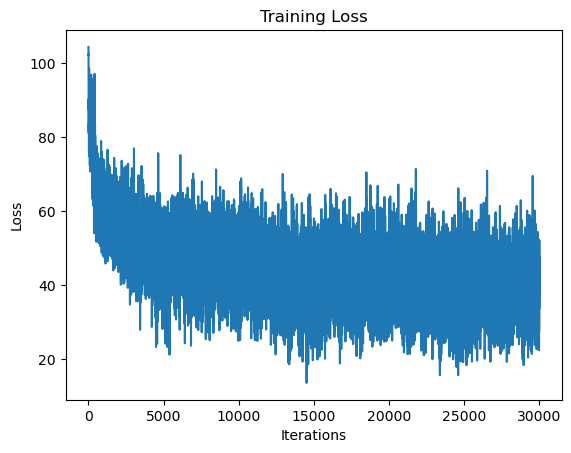

In [ ]:
import matplotlib.pyplot as plt

# 設定模型輸入維度、隱藏層維度與輸出維度
# 這裡輸入與輸出都以 vocab_size 為基準，適合字元級模型
input_dim, hidden_dim, output_dim = vocab_size, 100, vocab_size

# 設定 batch size
batch_size = 2

# 初始化 LSTM 參數
params = lstm_params_init(input_dim, hidden_dim, output_dim)

# 初始化 LSTM 狀態
H = lstm_state_init(batch_size, hidden_dim)

# 每段訓練序列的長度
seq_length = 25

# 設定 loss function，回傳 loss 與對輸出層的梯度
loss_function = lambda F, Y: fr.rnn_loss_grad(F, Y)  # ,util.loss_grad_least)

# 設定訓練回合數
epoches = 3

# 設定學習率
learning_rate = 1e-2

# 每個 epoch 允許的最大迭代次數
iterations = 10000

# 用來累積整體訓練過程中的 loss
losses = []

# 建立 AdaGrad optimizer
optimizer = fr.AdaGrad(params, learning_rate)

# 設定 momentum
momentum = 0.9

# 改用 SGD optimizer，並帶入 momentum
# 此行會覆蓋前面建立的 AdaGrad optimizer
optimizer = fr.SGD(params, learning_rate, momentum)

# 逐個 epoch 執行訓練
for epoch in range(epoches):
    # 建立連續字元序列資料迭代器
    data_it = character_seq_data_iter_consecutive(
        data, batch_size, seq_length, vocab_size, 100
    )

    # epoch_losses,param,H = rnn_train(params,data_it,learning_rate,iterations,loss_function,print_n=100)

    # 執行單一 epoch 的 LSTM 訓練
    epoch_losses, H = lstm_train_epoch(
        params, data_it, optimizer, iterations, loss_function, print_n=10
    )

    # 累加本 epoch 的所有 loss
    losses.extend(epoch_losses)

    # epoch_losses = np.array(epoch_losses).mean()
    # losses.append(epoch_losses)

# ===== 繪製訓練 loss 曲線 =====
plt.plot(losses[:])
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

## 文字生成

In [ ]:
def predict_lstm(params, prefix, n):
    # 取出 LSTM 與輸出層參數
    Wi, bi, Wf, bf, Wo, bo, Wc, bc, Wy, by = params

    # 由參數形狀推回詞彙大小與 hidden state 維度
    vocab_size, hidden_dim = Wi.shape[0] - Wy.shape[0], Wy.shape[0]

    # 初始化單筆預測時使用的 hidden state 與 cell state
    h, c = lstm_state_init(1, hidden_dim)

    # 先放入 prefix 的第一個字元索引，作為生成起點
    output = [char_to_idx[prefix[0]]]

    # 總共跑 prefix 長度加上欲生成長度，再扣掉已放入的第一個字元
    for t in range(len(prefix) + n - 1):
        # 將上一時間步的輸出字元轉成 one-hot，作為目前時間步輸入
        x = one_hot_idx(output[-1], vocab_size)

        # 執行單一步驟前向傳播，更新輸出與狀態
        z, h, c, _ = lstm_forward_step(params, x, h, c)

        # 在 prefix 範圍內時，直接使用 prefix 的下一個字元
        if t < len(prefix) - 1:
            output.append(char_to_idx[prefix[t + 1]])
        else:
            # 將輸出轉成機率分布
            p = np.exp(z) / np.sum(np.exp(z))

            # idx = int(p.argmax(axis=1))

            # 依機率分布隨機取樣下一個字元
            idx = np.random.choice(range(vocab_size), p=p.ravel())
            output.append(idx)

    # 將索引序列轉回字元字串
    return "".join([idx_to_char[i] for i in output])

In [40]:
str = predict_lstm(params, "he", 500)
print(str)

he,
A's good forching him have
Mangled you lord, not ore nightely,
In my lord, gracious may the most seition:
Priviley my bany I fell him,
To'd if Bectes' unteripers for our mother
To knew times to joy:
for nother, unclond behils feem will them, than
dok's in his divises;
And blood nothing surpon,
Tis quitious by the mither. If shall
There nothing but thine.

BUCKINGHAM:
O coullly this lord of him!
Lord of Their commo'd cromm but your quard,
Oftele; but strangmhough before
His dicivings from there
